# **Working with Labelled Data.**

In [ ]:
import pandas as pd

data = pd.read_csv("/content/drive/MyDrive/Copy of network_with_anomalies.csv")

data

,Time,Source,Destination,Length,label
0,0.897999,146.89.54.43,150.11.203.125,88,1
1,5.248364,52.44.231.29,203.202.131.185,90,1
2,9.621459,2400:51af:ff:c801:acb2:95e8:c603:3b6d,2001:6a28:200c:22a3:c279:bea3:816f:9e5b,74,1
3,2.079650,201.181.236.149,203.202.148.16,60,1
4,8.204602,203.202.148.16,197.158.24.212,60,1
...,...,...,...,...,...
1100998,8.685782,203.202.148.16,86.2.224.18,60,1
1100999,1.355066,38.165.37.228,163.66.151.28,1514,1
1101000,1.578330,81.31.127.33,203.202.148.16,60,1
1101001,5.163662,147.171.66.114,203.202.129.172,1514,1


*Removing Label column and preprocessing data, converting string to integer, using labelencoder*

In [ ]:
labels = data['label']
data.drop('label',axis=1, inplace=True)

In [ ]:
import ipaddress

def convert_ipv6_to_ipv4(ip):
    try:
        ip_obj = ipaddress.ip_address(ip)
        if isinstance(ip_obj, ipaddress.IPv6Address) and ip_obj.ipv4_mapped:
            return str(ip_obj.ipv4_mapped)
    except ValueError:
        pass
    return ip  # return original if not a valid IPv6 or not mapped

# Apply conversion to both columns
data['Source'] = data['Source'].apply(convert_ipv6_to_ipv4)
data['Destination'] = data['Destination'].apply(convert_ipv6_to_ipv4)

data

,Time,Source,Destination,Length
0,0.897999,146.89.54.43,150.11.203.125,88
1,5.248364,52.44.231.29,203.202.131.185,90
2,9.621459,2400:51af:ff:c801:acb2:95e8:c603:3b6d,2001:6a28:200c:22a3:c279:bea3:816f:9e5b,74
3,2.079650,201.181.236.149,203.202.148.16,60
4,8.204602,203.202.148.16,197.158.24.212,60
...,...,...,...,...
1100998,8.685782,203.202.148.16,86.2.224.18,60
1100999,1.355066,38.165.37.228,163.66.151.28,1514
1101000,1.578330,81.31.127.33,203.202.148.16,60
1101001,5.163662,147.171.66.114,203.202.129.172,1514


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for i in data:
  if data[i].dtype == 'object':
    data[i] = label_encoder.fit_transform(data[i])

data

,Time,Source,Destination,Length
0,0.897999,20606,98558,88
1,5.248364,73918,243511,90
2,9.621459,61269,230762,74
3,2.079650,48441,245089,60
4,8.204602,50115,218686,60
...,...,...,...,...
1100998,8.685782,50115,408850,60
1100999,1.355066,67038,125223,1514
1101000,1.578330,92995,245089,60
1101001,5.163662,20618,243315,1514


In [ ]:
!pip install pyod

*Training model*

In [ ]:
import pandas as pd
import numpy as np
from pyod.models.abod import ABOD
from sklearn.preprocessing import StandardScaler
import hashlib
import datetime

X = data[['Time', 'Source', 'Destination', 'Length']].values
# X_scaled = StandardScaler().fit_transform(X)

# --- 4. Apply FaSTABoD with k=2 (2 nearest neighbors) ---
clf = ABOD(n_neighbors=2)
clf.fit(X)

# --- 5. Append outlier scores ---
data['anomaly_score'] = clf.decision_scores_
data['is_outlier'] = clf.labels_



/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:4008: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
print(labels)


0          1
1          1
2          1
3          1
4          1
          ..
1100998    1
1100999    1
1101000    1
1101001    1
1101002    1
Name: label, Length: 1101003, dtype: int64


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(labels, data['is_outlier'])
print(f"Accuracy: {accuracy}")

Accuracy: 0.0


In [ ]:
data['is_outlier'].value_counts()

,count
is_outlier,
0,1101003


In [ ]:
labels.value_counts()

,count
label,
1,1048575
-1,52428


*Training model with different preprocessing approach*

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Copy of network_with_anomalies.csv")

df

,Time,Source,Destination,Length,label
0,0.897999,146.89.54.43,150.11.203.125,88,1
1,5.248364,52.44.231.29,203.202.131.185,90,1
2,9.621459,2400:51af:ff:c801:acb2:95e8:c603:3b6d,2001:6a28:200c:22a3:c279:bea3:816f:9e5b,74,1
3,2.079650,201.181.236.149,203.202.148.16,60,1
4,8.204602,203.202.148.16,197.158.24.212,60,1
...,...,...,...,...,...
1100998,8.685782,203.202.148.16,86.2.224.18,60,1
1100999,1.355066,38.165.37.228,163.66.151.28,1514,1
1101000,1.578330,81.31.127.33,203.202.148.16,60,1
1101001,5.163662,147.171.66.114,203.202.129.172,1514,1


In [ ]:
import pandas as pd
import ipaddress
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# === Step 1: Load Dataset ===


# === Step 2: Convert IPs to Integers ===
def ip_to_int(ip):
    try:
        return int(ipaddress.IPv4Address(ip))
    except:
        return 0  # or use np.nan and handle later

df['Source'] = df['Source'].apply(ip_to_int)
df['Destination'] = df['Destination'].apply(ip_to_int)

# === Step 3: Select Features for Anomaly Detection ===
features = df[['Source', 'Destination', 'Length']]

In [ ]:
features = features.astype(np.float64)

In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [ ]:
scaled_features

array([[-0.26266408,  0.31153647, -0.33672881],
       [-1.83411131,  1.12264205, -0.33384589],
       [-2.70475172, -1.95291995, -0.35690927],
       ...,
       [-1.35106801,  1.12264582, -0.37708972],
       [-0.24062917,  1.12264158,  1.71879452],
       [ 0.01953908, -1.05909201, -0.37708972]])

In [ ]:
clf = ABOD(n_neighbors=2,contamination=0.4)
clf.fit(features)

# --- 5. Append outlier scores ---
df['anomaly_score'] = clf.decision_scores_
df['is_outlier'] = clf.labels_


/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:4008: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
df['is_outlier'].value_counts()

,count
is_outlier,
0,1101003


# **Working with Unlabelled Data.**

In [ ]:
!pip install rarfile


In [ ]:
import rarfile

# Set path to your .rar file
rar_path = '/content/drive/MyDrive/Copy of dataset.rar'
# Set extraction destination
extract_path = './extracted/'

# Open and extract
with rarfile.RarFile(rar_path) as rf:
    rf.extractall(path=extract_path)

print("Extraction complete.")


Extraction complete.


In [ ]:
import pandas as pd

data =pd.read_csv("/content/extracted/dataset/data_5.csv")

data

,No.,Time,Source,Destination,Protocol,Length,Info
0,1,0.000000,185.182.4.232,163.66.177.5,TCP,54,46366 > 49489 [SYN] Seq=0 Win=1024 Len=0
1,2,0.000022,61.164.228.121,163.66.128.38,TCP,54,63207 > 12345 [SYN] Seq=0 Win=1024 Len=0
2,3,0.000034,204.195.47.146,203.202.136.235,IPv4,167,[Packet size limited during capture]
3,4,0.000043,80.73.197.96,163.66.249.16,TCP,54,51324 > 6226 [SYN] Seq=0 Win=1024 Len=0
4,5,0.000111,36.238.108.101,203.202.148.16,ICMP,60,"Echo (ping) reply id=0x3140, seq=4727/30482..."
...,...,...,...,...,...,...,...
1048570,1048571,13.267210,203.202.137.249,85.255.240.222,DNS,105,Standard query 0xf2a2[Packet size limited duri...
1048571,1048572,13.267281,203.202.129.172,126.184.187.160,TCP,1474,80 > 58530 [ACK] Seq=69401729 Ack=1 Win=480 ...
1048572,1048573,13.267304,203.202.129.172,126.184.187.160,TCP,1474,80 > 58530 [ACK] Seq=69403137 Ack=1 Win=480 ...
1048573,1048574,13.267312,203.202.148.16,84.250.223.183,ICMP,60,"Echo (ping) request id=0xf53f, seq=5247/32532..."


In [ ]:
import pandas as pd
import re

def extract_features(df):
    def parse_info(row):
        info = row['Info']
        protocol = row['Protocol']
        features = {}

        if protocol == 'TCP':
            features['TCP_Flag_SYN'] = int('[SYN]' in info)
            features['TCP_Flag_ACK'] = int('[ACK]' in info)
            features['TCP_Flag_FIN'] = int('[FIN]' in info)
            features['TCP_Flag_RST'] = int('[RST]' in info)

            m = re.search(r'(\d+) > (\d+)', info)
            if m:
                features['TCP_Source_Port'] = int(m.group(1))
                features['TCP_Dest_Port'] = int(m.group(2))

            m = re.search(r'Seq=(\d+)', info)
            if m:
                features['TCP_Seq'] = int(m.group(1))

            m = re.search(r'Win=(\d+)', info)
            if m:
                features['TCP_Window_Size'] = int(m.group(1))

            m = re.search(r'Len=(\d+)', info)
            if m:
                features['TCP_Payload_Length'] = int(m.group(1))

        elif protocol == 'ICMP':
            features['ICMP_Echo_Reply'] = int('Echo (ping) reply' in info)
            m = re.search(r'id=0x([0-9a-fA-F]+)', info)
            if m:
                features['ICMP_ID'] = int(m.group(1), 16)
            m = re.search(r'seq=(\d+)', info)
            if m:
                features['ICMP_Seq'] = int(m.group(1))

        elif protocol == 'IPv4':
            features['IPv4_Size_Limited'] = int('Packet size limited' in info)

        return pd.Series(features)

    feature_df = df.apply(parse_info, axis=1)
    return pd.concat([df, feature_df], axis=1).fillna(0)

# Example usage

df_features = extract_features(data)


In [ ]:
df_features

,No.,Time,Source,Destination,Protocol,Length,Info,ICMP_Echo_Reply,ICMP_ID,ICMP_Seq,IPv4_Size_Limited,TCP_Flag_ACK,TCP_Flag_FIN,TCP_Flag_RST,TCP_Flag_SYN,TCP_Payload_Length,TCP_Seq,TCP_Window_Size
0,1,0.000000,185.182.4.232,163.66.177.5,TCP,54,46366 > 49489 [SYN] Seq=0 Win=1024 Len=0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1024.0
1,2,0.000022,61.164.228.121,163.66.128.38,TCP,54,63207 > 12345 [SYN] Seq=0 Win=1024 Len=0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1024.0
2,3,0.000034,204.195.47.146,203.202.136.235,IPv4,167,[Packet size limited during capture],0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0.000043,80.73.197.96,163.66.249.16,TCP,54,51324 > 6226 [SYN] Seq=0 Win=1024 Len=0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1024.0
4,5,0.000111,36.238.108.101,203.202.148.16,ICMP,60,"Echo (ping) reply id=0x3140, seq=4727/30482...",1.0,12608.0,4727.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,1048571,13.267210,203.202.137.249,85.255.240.222,DNS,105,Standard query 0xf2a2[Packet size limited duri...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1048571,1048572,13.267281,203.202.129.172,126.184.187.160,TCP,1474,80 > 58530 [ACK] Seq=69401729 Ack=1 Win=480 ...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1408.0,69401729.0,480.0
1048572,1048573,13.267304,203.202.129.172,126.184.187.160,TCP,1474,80 > 58530 [ACK] Seq=69403137 Ack=1 Win=480 ...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1408.0,69403137.0,480.0
1048573,1048574,13.267312,203.202.148.16,84.250.223.183,ICMP,60,"Echo (ping) request id=0xf53f, seq=5247/32532...",0.0,62783.0,5247.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_features.drop(['No.','Info'],axis=1,inplace=True)
df_features

,Time,Source,Destination,Protocol,Length,ICMP_Echo_Reply,ICMP_ID,ICMP_Seq,IPv4_Size_Limited,TCP_Flag_ACK,TCP_Flag_FIN,TCP_Flag_RST,TCP_Flag_SYN,TCP_Payload_Length,TCP_Seq,TCP_Window_Size
0,0.000000,185.182.4.232,163.66.177.5,TCP,54,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1024.0
1,0.000022,61.164.228.121,163.66.128.38,TCP,54,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1024.0
2,0.000034,204.195.47.146,203.202.136.235,IPv4,167,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000043,80.73.197.96,163.66.249.16,TCP,54,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1024.0
4,0.000111,36.238.108.101,203.202.148.16,ICMP,60,1.0,12608.0,4727.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,13.267210,203.202.137.249,85.255.240.222,DNS,105,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1048571,13.267281,203.202.129.172,126.184.187.160,TCP,1474,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1408.0,69401729.0,480.0
1048572,13.267304,203.202.129.172,126.184.187.160,TCP,1474,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1408.0,69403137.0,480.0
1048573,13.267312,203.202.148.16,84.250.223.183,ICMP,60,0.0,62783.0,5247.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_features.to_csv("features.csv",index=False)

In [ ]:
import ipaddress

def ip_to_int(ip):
    try:
        return int(ipaddress.IPv4Address(ip))
    except:
        return 0  # or np.nan if you prefer

# Convert source and destination IPs
df_features['Source'] = df_features['Source'].apply(ip_to_int)
df_features['Destination'] = df_features['Destination'].apply(ip_to_int)


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_features['Protocol'] = le.fit_transform(df_features['Protocol'])

In [ ]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 16 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Time                1048575 non-null  float64
 1   Source              1048575 non-null  int64  
 2   Destination         1048575 non-null  int64  
 3   Protocol            1048575 non-null  int64  
 4   Length              1048575 non-null  int64  
 5   ICMP_Echo_Reply     1048575 non-null  float64
 6   ICMP_ID             1048575 non-null  float64
 7   ICMP_Seq            1048575 non-null  float64
 8   IPv4_Size_Limited   1048575 non-null  float64
 9   TCP_Flag_ACK        1048575 non-null  float64
 10  TCP_Flag_FIN        1048575 non-null  float64
 11  TCP_Flag_RST        1048575 non-null  float64
 12  TCP_Flag_SYN        1048575 non-null  float64
 13  TCP_Payload_Length  1048575 non-null  float64
 14  TCP_Seq             1048575 non-null  float64
 15  TCP_Window_Size

In [ ]:
!pip install pyod

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 5.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from pyod.models.abod import ABOD
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline



# Drop Time if you don't want time-based patterns
X = df_features.drop(columns=['Time'])


model = make_pipeline(
    StandardScaler(),
    ABOD(method='fast', n_neighbors=20)  # You can tune `n_neighbors`
)

# Fit and predict
model.fit(X)
abod_scores = model.named_steps['abod'].decision_scores_  # Raw anomaly scores
abod_labels = model.named_steps['abod'].labels_           # 0 = inlier, 1 = outlier

# Add to original DataFrame
df['abod_score'] = abod_scores
df['abod_label'] = abod_labels

# View top anomalies
print(df.sort_values('abod_score', ascending=False).head())


/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:4008: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


NameError: name 'df' is not defined

In [ ]:
df_features["labels"] = abod_labels

In [ ]:
df_features["labels"].value_counts()

,count
labels,
0,1048575


<ipython-input-34-ca176e1c231f>:27: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


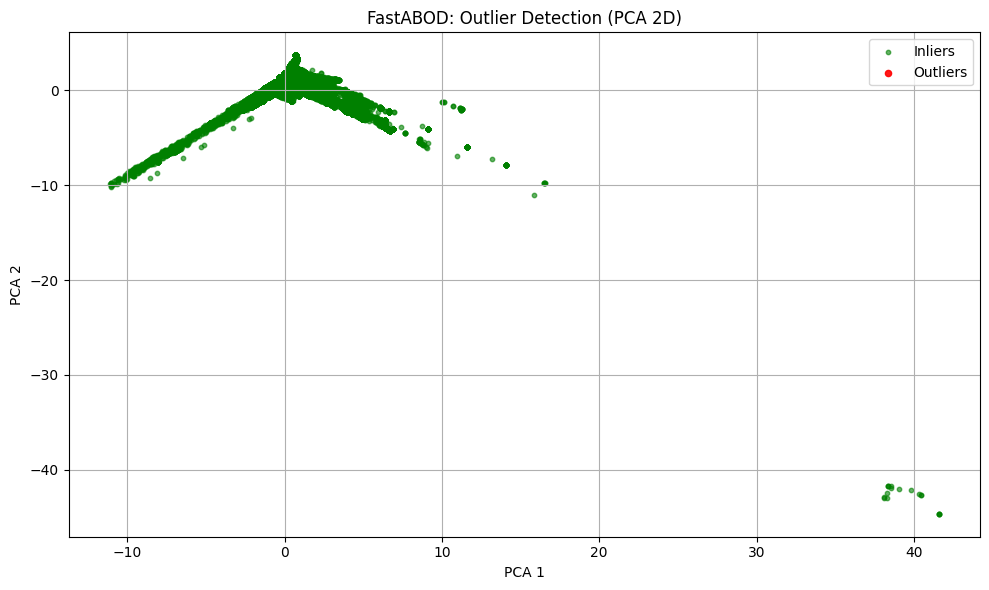

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from pyod.models.abod import ABOD
from sklearn.pipeline import make_pipeline





labels = model.named_steps['abod'].labels_

# Reduce to 2D with PCA for visualization
X_scaled = model.named_steps['standardscaler'].transform(X)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[labels == 0, 0], X_pca[labels == 0, 1], c='green', s=10, label='Inliers', alpha=0.6)
plt.scatter(X_pca[labels == 1, 0], X_pca[labels == 1, 1], c='red', s=20, label='Outliers', alpha=0.9)
plt.title('FastABOD: Outlier Detection (PCA 2D)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
important_features = [
    'Source', 'Destination', 'Length',
    'TCP_Flag_SYN', 'TCP_Flag_ACK', 'TCP_Flag_RST',
    'TCP_Payload_Length', 'TCP_Seq', 'TCP_Window_Size'
]
X = df_features[important_features]


In [ ]:
import pandas as pd
from pyod.models.abod import ABOD
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline



# Drop Time if you don't want time-based patterns
X = df_features.drop(columns=['Time'])


model = make_pipeline(
    StandardScaler(),
    ABOD(method='fast', n_neighbors=10)
)

# Fit and predict
model.fit(X)
abod_scores = model.named_steps['abod'].decision_scores_  # Raw anomaly scores
abod_labels = model.named_steps['abod'].labels_           # 0 = inlier, 1 = outlier




/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:4008: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


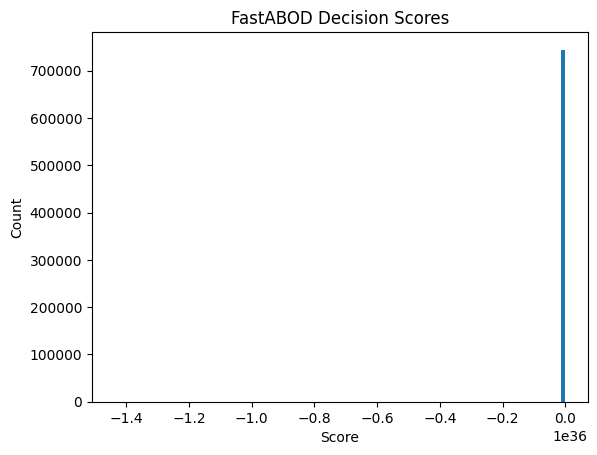

In [ ]:
import matplotlib.pyplot as plt

scores = model.named_steps['abod'].decision_scores_
plt.hist(scores, bins=100)
plt.title('FastABOD Decision Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()


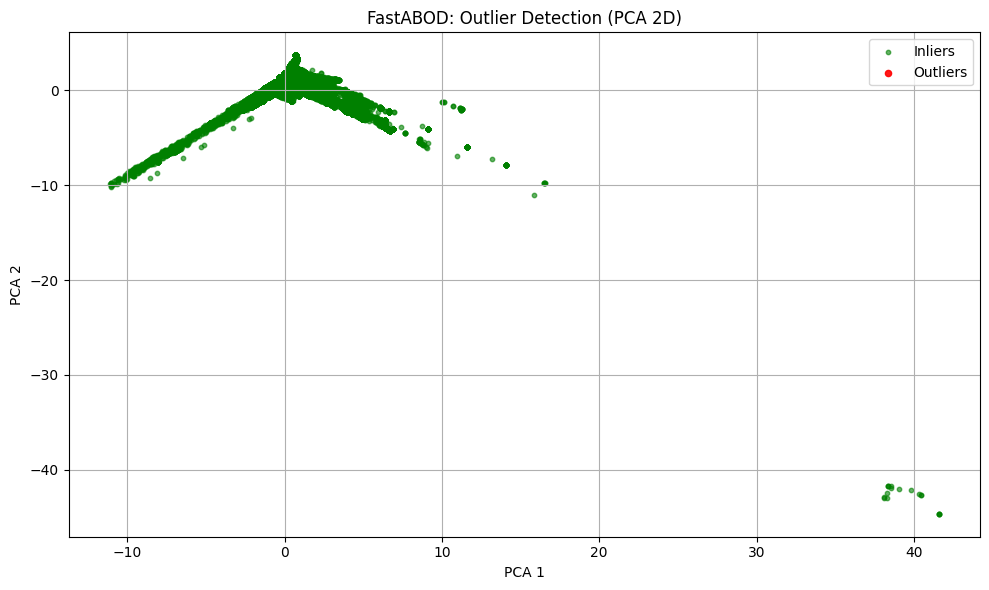

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from pyod.models.abod import ABOD
from sklearn.pipeline import make_pipeline





labels = model.named_steps['abod'].labels_

# Reduce to 2D with PCA for visualization
X_scaled = model.named_steps['standardscaler'].transform(X)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[labels == 0, 0], X_pca[labels == 0, 1], c='green', s=10, label='Inliers', alpha=0.6)
plt.scatter(X_pca[labels == 1, 0], X_pca[labels == 1, 1], c='red', s=20, label='Outliers', alpha=0.9)
plt.title('FastABOD: Outlier Detection (PCA 2D)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
